In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("social_interaction_level_medium.csv")

In [3]:
dataset

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14.0,7.9,7.4,2.9,3.01,1.5,2.0,2.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
1,19.0,1.9,8.0,2.9,3.22,0.8,8.0,1.0,10.0,0.0,0.0,0.0,1.0,0.0,0.0
2,17.0,1.3,7.6,0.5,3.92,0.0,2.0,4.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0
3,15.0,7.4,6.9,1.6,3.48,0.8,1.0,7.0,9.0,0.0,1.0,0.0,1.0,0.0,1.0
4,15.0,4.7,4.9,3.0,2.37,1.4,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18.0,6.8,6.6,2.0,2.76,1.0,3.0,4.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0
1196,16.0,2.3,8.0,1.9,2.12,0.4,7.0,4.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0
1197,14.0,1.7,8.7,0.7,3.98,0.8,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1198,15.0,3.9,8.5,2.1,3.19,0.6,7.0,9.0,9.0,0.0,1.0,0.0,0.0,0.0,0.0


In [4]:
highest_academic_row = dataset[dataset['academic_performance'] == dataset['academic_performance'].max()]

In [5]:
highest_academic_row 

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
122,17.0,6.0,8.8,1.3,4.0,0.9,8.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,1.0
412,13.0,1.1,7.0,1.9,4.0,0.9,2.0,9.0,6.0,0.0,0.0,1.0,0.0,0.0,1.0
661,14.0,6.4,5.6,0.8,4.0,1.9,5.0,1.0,3.0,0.0,1.0,1.0,0.0,0.0,1.0
979,18.0,7.7,6.6,1.6,4.0,1.9,3.0,3.0,9.0,0.0,1.0,0.0,0.0,0.0,0.0
1058,13.0,1.3,8.7,0.9,4.0,0.1,10.0,9.0,9.0,0.0,0.0,0.0,1.0,1.0,0.0


In [6]:
lowest_academic_row = dataset[dataset['academic_performance'] == dataset['academic_performance'].min()]

In [7]:
lowest_academic_row

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
900,16.0,1.4,5.7,1.8,2.0,1.4,4.0,8.0,7.0,0.0,0.0,0.0,0.0,1.0,0.0
930,17.0,4.8,5.6,1.6,2.0,1.3,3.0,8.0,4.0,0.0,1.0,0.0,1.0,1.0,0.0
1082,14.0,5.0,6.2,1.0,2.0,1.5,5.0,6.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [8]:
def quanQual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        #print(columnName)
        if(dataset[columnName].dtype=='O'):
            #print("qual")
            qual.append(columnName)
        else:
            #print("quan")
            quan.append(columnName)
    return quan,qual


In [10]:
quanQual(dataset)

(['age',
  'daily_social_media_hours',
  'sleep_hours',
  'screen_time_before_sleep',
  'academic_performance',
  'physical_activity',
  'stress_level',
  'anxiety_level',
  'addiction_level',
  'depression_label',
  'gender_male',
  'platform_usage_Instagram',
  'platform_usage_TikTok',
  'social_interaction_level_low',
  'social_interaction_level_medium'],
 [])

In [11]:
quan,qual=quanQual(dataset)

In [12]:
quan

['age',
 'daily_social_media_hours',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'stress_level',
 'anxiety_level',
 'addiction_level',
 'depression_label',
 'gender_male',
 'platform_usage_Instagram',
 'platform_usage_TikTok',
 'social_interaction_level_low',
 'social_interaction_level_medium']

In [15]:
def Univariate(dataset,quan):
    descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%",
                               "Q3:75%","99%","Q4:100%","IQR","1.5rule","Lesser","Greater",
                                    "Min","Max","kurtosis","skew","Var","Std"],columns=quan)
    for columnName in quan:
        descriptive[columnName]["Mean"]=dataset[columnName].mean()
        descriptive[columnName]["Median"]=dataset[columnName].median()
        descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
        descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
        descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
        descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
        descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
        descriptive[columnName]["IQR"]=descriptive[columnName]["Q3:75%"]-descriptive[columnName]["Q1:25%"]
        descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
        descriptive[columnName]["Lesser"]=descriptive[columnName]["Q1:25%"]-descriptive[columnName]["1.5rule"]
        descriptive[columnName]["Greater"]=descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
        descriptive[columnName]["Min"]=dataset[columnName].min()
        descriptive[columnName]["Max"]=dataset[columnName].max()
        descriptive[columnName]["kurtosis"]=dataset[columnName].kurtosis()
        descriptive[columnName]["skew"]=dataset[columnName].skew()
        descriptive[columnName]["Var"]=dataset[columnName].var()
        descriptive[columnName]["Std"]=dataset[columnName].std()
    return descriptive

In [16]:
Univariate(dataset,quan)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
Mean,15.9283,4.53667,6.44942,1.74033,2.99038,1.0145,5.44583,5.63667,5.565,0.0258333,0.5125,0.3425,0.331667,0.345833,0.346667
Median,16,4.5,6.5,1.8,2.99,1,5,6,6,0,1,0,0,0,0
Mode,13,3.5,6.8,1.4,2.36,1.9,4,6,6,0,1,0,0,0,0
Q1:25%,14,2.8,5.2,1.1,2.5,0.5,3,3,3,0,0,0,0,0,0
Q2:50%,16,4.5,6.5,1.8,2.99,1,5,6,6,0,1,0,0,0,0
Q3:75%,18,6.3,7.6,2.4,3.48,1.5,8,8,8,0,1,1,1,1,1
99%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Q4:100%,19,8,9,3,4,2,10,10,10,1,1,1,1,1,1
IQR,4,3.5,2.4,1.3,0.98,1,5,5,5,0,1,1,1,1,1
1.5rule,6,5.25,3.6,1.95,1.47,1.5,7.5,7.5,7.5,0,1.5,1.5,1.5,1.5,1.5


In [17]:
dataset.columns

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label',
       'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok',
       'social_interaction_level_low', 'social_interaction_level_medium'],
      dtype='object')

In [18]:
independent=dataset[["age","daily_social_media_hours","sleep_hours","screen_time_before_sleep","academic_performance","physical_activity","stress_level","anxiety_level","addiction_level","depression_label","gender_male","platform_usage_Instagram","platform_usage_TikTok","social_interaction_level_low"]]

In [19]:
dependent=dataset[["social_interaction_level_medium"]]

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split 
import time
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import pickle
import matplotlib.pyplot as plt

In [21]:
    def selectkbest(indep_X,dep_Y,n):
        test = SelectKBest(score_func=chi2, k=n)
        fit1= test.fit(indep_X,dep_Y)
        # summarize scores       
        selectk_features = fit1.transform(indep_X)
        return selectk_features
    
    def split_scalar(indep_X,dep_Y):
        X_train, X_test, y_train, y_test = train_test_split(indep_X, dep_Y, test_size = 0.25, random_state = 0)
        sc = StandardScaler()
        X_train = sc.fit_transform(X_train)
        X_test = sc.transform(X_test)    
        return X_train, X_test, y_train, y_test
    
    def r2_prediction(regressor,X_test,y_test):
        y_pred = regressor.predict(X_test)
        from sklearn.metrics import r2_score
        r2=r2_score(y_test,y_pred)
        return r2
 
    def Linear(X_train,y_train,X_test):       
        # Fitting K-NN to the Training set
        from sklearn.linear_model import LinearRegression
        regressor = LinearRegression()
        regressor.fit(X_train, y_train)
        r2=r2_prediction(regressor,X_test,y_test)
        return  r2   
    
    def svm_linear(X_train,y_train,X_test):
                
        from sklearn.svm import SVR
        regressor = SVR(kernel = 'linear')
        regressor.fit(X_train, y_train)
        r2=r2_prediction(regressor,X_test,y_test)
        return  r2  
    
    def svm_NL(X_train,y_train,X_test):
                
        from sklearn.svm import SVR
        regressor = SVR(kernel = 'rbf')
        regressor.fit(X_train, y_train)
        r2=r2_prediction(regressor,X_test,y_test)
        return  r2  
     

    def Decision(X_train,y_train,X_test):
        
        # Fitting K-NN to the Training setC
        from sklearn.tree import DecisionTreeRegressor
        regressor = DecisionTreeRegressor(random_state = 0)
        regressor.fit(X_train, y_train)
        r2=r2_prediction(regressor,X_test,y_test)
        return  r2  
     

    def random(X_train,y_train,X_test):       
        # Fitting K-NN to the Training set
        from sklearn.ensemble import RandomForestRegressor
        regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
        regressor.fit(X_train, y_train)
        r2=r2_prediction(regressor,X_test,y_test)
        return  r2 

In [36]:
def selectk_regression(acclin,accsvml,accsvmnl,accdes,accrf): 
    
    dataframe=pd.DataFrame(index=['ChiSquare'],columns=['Linear','SVMl','SVMnl','Decision','Random'
                                                                                     ])

    for number,idex in enumerate(dataframe.index):
        
        dataframe['Linear'][idex]=acclin[number]       
        dataframe['SVMl'][idex]=accsvml[number]
        dataframe['SVMnl'][idex]=accsvmnl[number]
        dataframe['Decision'][idex]=accdes[number]
        dataframe['Random'][idex]=accrf[number]
    return dataframe
    
dataset1=pd.read_csv("social_interaction_level_medium.csv",index_col=None)

df2=dataset1

df2 = pd.get_dummies(df2, drop_first=True)
indep_X=df2.drop('social_interaction_level_medium',1)
dep_Y=df2['social_interaction_level_medium']




In [43]:
kbest=selectkbest(indep_X,dep_Y,2)      

acclin=[]
accsvml=[]
accsvmnl=[]
accdes=[]
accrf=[]

In [44]:
X_train, X_test, y_train, y_test=split_scalar(kbest,dep_Y)  
for i in kbest:   
    r2_lin=Linear(X_train,y_train,X_test)
    acclin.append(r2_lin)
    
    r2_sl=svm_linear(X_train,y_train,X_test)    
    accsvml.append(r2_sl)
    
    r2_NL=svm_NL(X_train,y_train,X_test)
    accsvmnl.append(r2_NL)
    
    r2_d=Decision(X_train,y_train,X_test)
    accdes.append(r2_d)
    
    r2_r=random(X_train,y_train,X_test)
    accrf.append(r2_r)
    
    
result=selectk_regression(acclin,accsvml,accsvmnl,accdes,accrf)


In [39]:
result #5

,Linear,SVMl,SVMnl,Decision,Random
ChiSquare,0.276909,-0.00804106,-0.0649925,-0.133907,-0.0454931


In [42]:
result #3

,Linear,SVMl,SVMnl,Decision,Random
ChiSquare,0.278867,-0.00778145,-0.106058,0.279702,0.27841


In [45]:
result #2

,Linear,SVMl,SVMnl,Decision,Random
ChiSquare,0.279279,-0.00778093,-0.105574,0.280383,0.280268


In [46]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob

C:\Anaconda 3\envs\aiml\lib\site-packages\ipykernel_launcher.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  """


Mean=2.990, Standard Deviation=0.577
The area between range(1,5):1.0012090296894178


1.0012090296894178

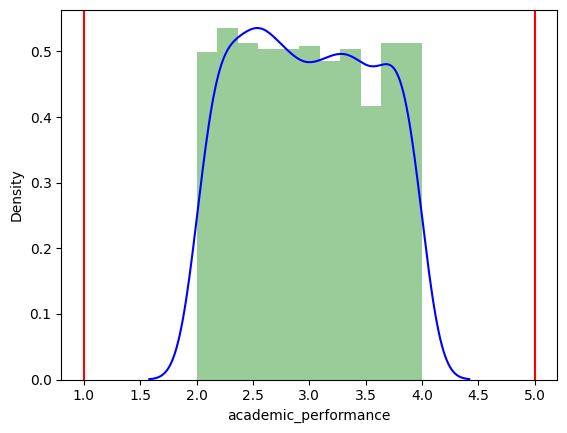

In [49]:
get_pdf_probability(dataset["academic_performance"],1,5)